In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

In [2]:
import requests

data = 'https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/car_fuel_efficiency_2026.csv'

response = requests.get(data)
response.raise_for_status()

with open('data-week-6.csv', 'wb') as f:
    f.write(response.content)

d:\machine-learning-zoomcamp-2026-course\.venv\Lib\site-packages\requests\__init__.py:92: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


In [3]:
df = pd.read_csv('data-week-6.csv')
df.head(7)

,model_year,origin,fuel_type,drivetrain,num_doors,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,fuel_efficiency_mpg
0,2006,Europe,Gasoline,Front-wheel drive,4,2180,6,243.0,3870,NaN,31.9
1,2008,Europe,Diesel,Front-wheel drive,4,2390,6,272.0,4210,NaN,31.3
2,1996,Asia,Gasoline,Front-wheel drive,5,2320,6,267.0,4240,17.3,27.5
3,1989,Europe,Gasoline,Front-wheel drive,4,2130,6,258.0,4490,18.7,28.5
4,1994,USA,Diesel,Front-wheel drive,3,2580,7,304.0,4510,17.5,31.0
5,2007,USA,Hybrid,Front-wheel drive,2,2290,6,266.0,4260,18.8,31.2
6,1992,Asia,Gasoline,Front-wheel drive,2,2270,6,250.0,4310,21.7,26.8


In [4]:
df.isnull().sum()

model_year               0
origin                   0
fuel_type                0
drivetrain               0
num_doors                0
engine_displacement      0
num_cylinders            0
horsepower             877
vehicle_weight           0
acceleration           264
fuel_efficiency_mpg      0
dtype: int64

In [5]:
numerical_features=list(df.select_dtypes(include='number').columns)

In [6]:
numerical_features

['model_year',
 'num_doors',
 'engine_displacement',
 'num_cylinders',
 'horsepower',
 'vehicle_weight',
 'acceleration',
 'fuel_efficiency_mpg']

In [7]:
for n in numerical_features:
    df[n]=df[n].fillna(0)

In [8]:
df.isnull().sum()

model_year             0
origin                 0
fuel_type              0
drivetrain             0
num_doors              0
engine_displacement    0
num_cylinders          0
horsepower             0
vehicle_weight         0
acceleration           0
fuel_efficiency_mpg    0
dtype: int64

In [9]:
from sklearn.model_selection import train_test_split


In [10]:
df_full_train, df_test = train_test_split(df, test_size=0.2, random_state=1)
df_train, df_val = train_test_split(
    df_full_train, test_size=0.25, random_state=1
)

In [11]:
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

In [12]:
y_train = df_train.fuel_efficiency_mpg.values
y_val = df_val.fuel_efficiency_mpg.values
y_test = df_test.fuel_efficiency_mpg.values

In [13]:
del df_train['fuel_efficiency_mpg']
del df_val['fuel_efficiency_mpg']
del df_test['fuel_efficiency_mpg']

In [14]:
y_full_train = df_full_train.fuel_efficiency_mpg.values
del df_full_train['fuel_efficiency_mpg']


In [15]:
from sklearn.feature_extraction import DictVectorizer


In [16]:
train_dicts = df_train.to_dict(orient='records')

dv = DictVectorizer(sparse=False)
X_train = dv.fit_transform(train_dicts)

In [17]:
from sklearn.tree import DecisionTreeRegressor
dt = DecisionTreeRegressor(max_depth=1)
dt.fit(X_train, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",1
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split among considered features for this split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: splitting may inspect more than ``max_features`` features ifneeded to find a valid split.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with 

In [18]:
val_dicts = df_val.to_dict(orient='records')
X_val = dv.transform(val_dicts)

In [19]:
from sklearn.tree import export_text


In [20]:
print(export_text(dt, feature_names=list(dv.get_feature_names_out())))


|--- model_year <= 1997.50
|   |--- value: [28.61]
|--- model_year >  1997.50
|   |--- value: [31.17]



In [21]:
from sklearn.ensemble import RandomForestRegressor


In [22]:
rf = RandomForestRegressor(n_estimators=10, random_state=1,n_jobs=-1)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_val)


In [23]:
def rmse(y, y_pred):
    error = y - y_pred
    se = error ** 2
    mse = se.mean()
    return np.sqrt(mse)

In [24]:
round(rmse(y_val,y_pred),3)

np.float64(1.834)

In [25]:
scores = []
for n in [10, 50, 100, 150]:
    rf = RandomForestRegressor(n_estimators=n, random_state=1,n_jobs=-1)
    rf.fit(X_train, y_train)
    y_pred = rf.predict(X_val)
    # print(f"rmse at n_estimators {n} is {round(rmse(y_val,y_pred),3)}")
    score=round(rmse(y_val,y_pred),3)
    scores.append((n, score))

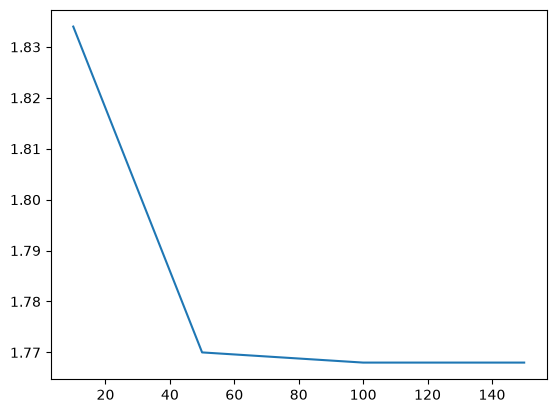

In [26]:
df_scores = pd.DataFrame(scores, columns=['n_estimators', 'rmse'])
plt.plot(df_scores.n_estimators, df_scores.rmse)

In [27]:
scores = []
for d in [10, 15, 20, 25]:
    for n in [10, 50, 100, 150]:
        rf = RandomForestRegressor(n_estimators=n, random_state=1,n_jobs=-1,max_depth=d)
        rf.fit(X_train, y_train)
        y_pred = rf.predict(X_val)
        score=round(rmse(y_val,y_pred),3)
        scores.append((d, n, score))
        # print(f"rmse at n_estimators {n} at {md} is {round(rmse(y_val,y_pred),3)}")

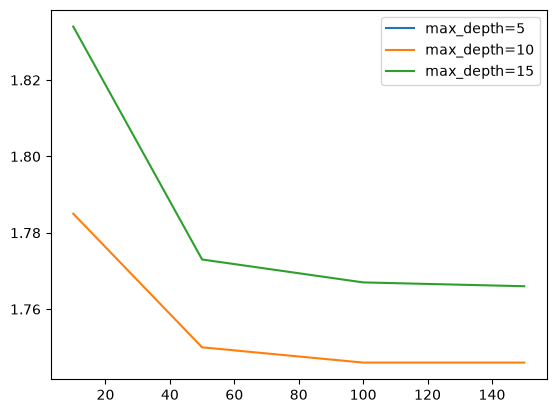

In [28]:
columns = ['max_depth', 'n_estimators', 'rmse']
df_scores = pd.DataFrame(scores, columns=columns)

for d in [5, 10, 15]:
    df_subset = df_scores[df_scores.max_depth == d]

    plt.plot(df_subset.n_estimators, df_subset.rmse,
             label='max_depth=%d' % d)

plt.legend()

In [29]:
rf = RandomForestRegressor(n_estimators=10,max_depth=20, random_state=1,n_jobs=-1)
rf.fit(X_train, y_train)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",10
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",20
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",1
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_l

In [31]:
features = dv.get_feature_names_out()


In [32]:
features 

array(['acceleration', 'drivetrain=All-wheel drive',
       'drivetrain=Front-wheel drive', 'drivetrain=Rear-wheel drive',
       'engine_displacement', 'fuel_type=Diesel', 'fuel_type=Gasoline',
       'fuel_type=Hybrid', 'horsepower', 'model_year', 'num_cylinders',
       'num_doors', 'origin=Asia', 'origin=Europe', 'origin=USA',
       'vehicle_weight'], dtype=object)

In [34]:
features = [
    'vehicle_weight',
    'horsepower',
    'acceleration',
    'engine_displacement'
]

for feature, importance in sorted(
    zip(features, rf.feature_importances_),
    key=lambda x: x[1],
    reverse=True
):
    print(feature, importance)

vehicle_weight 0.0554662237542245
acceleration 0.020004803233558292
horsepower 0.007872747899466634
engine_displacement 0.005636066805696861


In [66]:
import xgboost as xgb


In [83]:
def parse_xgb_output(output):
    results = []

    for line in output.stdout.strip().split('\n'):
        if not line.startswith('['):
            continue

        it_line, train_line, val_line = line.split('\t')

        it = int(it_line.strip('[]'))
        train = float(train_line.split(':')[1])
        val = float(val_line.split(':')[1])

        results.append((it, train, val))

    columns = ['num_iter', 'train_rmse', 'val_rmse']
    df_results = pd.DataFrame(results, columns=columns)

    return df_results

In [84]:
features = list(dv.get_feature_names_out())
dtrain = xgb.DMatrix(X_train, label=y_train, feature_names=features)
dval = xgb.DMatrix(X_val, label=y_val, feature_names=features)

In [85]:
watchlist = [(dtrain, 'train'), (dval, 'val')]

In [86]:
from IPython.utils.capture import capture_output

scores = {}

for n in [0.3,0.1]:

    xgb_params = {
    'eta': n, 
    'max_depth': 6,
    'min_child_weight': 1,
    
    'objective': 'reg:squarederror',
    'nthread': 8,
    
    'seed': 1,
    'verbosity': 1,
    }

    with capture_output() as captured:
        model = xgb.train(
            xgb_params,
            dtrain,
            num_boost_round=100,
            verbose_eval=5,
            evals=watchlist
        )

    print("STDOUT:", repr(captured.stdout))
    print("STDERR:", repr(captured.stderr))
    key = 'eta=%s' % xgb_params['eta']
    scores[key] = parse_xgb_output(captured)


STDOUT: '[0]\ttrain-rmse:2.40653\tval-rmse:2.46782\n[5]\ttrain-rmse:1.59328\tval-rmse:1.76216\n[10]\ttrain-rmse:1.47125\tval-rmse:1.73205\n[15]\ttrain-rmse:1.41908\tval-rmse:1.73512\n[20]\ttrain-rmse:1.39368\tval-rmse:1.73766\n[25]\ttrain-rmse:1.35837\tval-rmse:1.74359\n[30]\ttrain-rmse:1.33243\tval-rmse:1.74548\n[35]\ttrain-rmse:1.29290\tval-rmse:1.75198\n[40]\ttrain-rmse:1.25326\tval-rmse:1.76296\n[45]\ttrain-rmse:1.21527\tval-rmse:1.77244\n[50]\ttrain-rmse:1.18645\tval-rmse:1.77517\n[55]\ttrain-rmse:1.14797\tval-rmse:1.78668\n[60]\ttrain-rmse:1.10265\tval-rmse:1.79401\n[65]\ttrain-rmse:1.06590\tval-rmse:1.80143\n[70]\ttrain-rmse:1.04604\tval-rmse:1.80444\n[75]\ttrain-rmse:1.02727\tval-rmse:1.80682\n[80]\ttrain-rmse:0.99487\tval-rmse:1.81308\n[85]\ttrain-rmse:0.96970\tval-rmse:1.81600\n[90]\ttrain-rmse:0.94986\tval-rmse:1.82135\n[95]\ttrain-rmse:0.91805\tval-rmse:1.82544\n[99]\ttrain-rmse:0.90106\tval-rmse:1.82646\n'
STDERR: ''
STDOUT: '[0]\ttrain-rmse:2.74739\tval-rmse:2.78635\n[5]\

In [87]:
print(scores)

{'eta=0.3':     num_iter  train_rmse  val_rmse
0          0     2.40653   2.46782
1          5     1.59328   1.76216
2         10     1.47125   1.73205
3         15     1.41908   1.73512
4         20     1.39368   1.73766
5         25     1.35837   1.74359
6         30     1.33243   1.74548
7         35     1.29290   1.75198
8         40     1.25326   1.76296
9         45     1.21527   1.77244
10        50     1.18645   1.77517
11        55     1.14797   1.78668
12        60     1.10265   1.79401
13        65     1.06590   1.80143
14        70     1.04604   1.80444
15        75     1.02727   1.80682
16        80     0.99487   1.81308
17        85     0.96970   1.81600
18        90     0.94986   1.82135
19        95     0.91805   1.82544
20        99     0.90106   1.82646, 'eta=0.1':     num_iter  train_rmse  val_rmse
0          0     2.74739   2.78635
1          5     2.12109   2.20428
2         10     1.80592   1.93152
3         15     1.64286   1.80346
4         20     1.55847   1.75

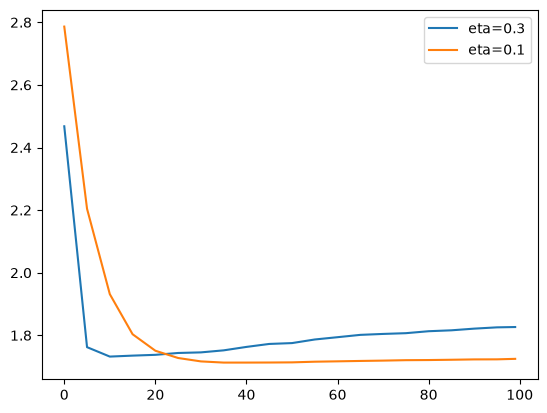

In [90]:
for key, df_score in scores.items():
    plt.plot(df_score.num_iter, df_score.val_rmse, label=key)

# plt.ylim(0.8, .84)
plt.legend()